In [33]:
import numpy as np
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras.layers import Layer
import os

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from tensorflow.keras.utils import to_categorical

In [3]:
import sys
sys.path.append('../data_preprocessing')

In [4]:
import feature_engineering_scaling as fes

In [ ]:
import RNN_preprocessing_sep_chain as rp

In [ ]:
# Load the saved models
model1 = load_model("../models/model_lstm_214.h5")
model2 = load_model("../models/model_lstm_212.h5")

2025-02-28 16:17:10.153377: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# Predictions of the Model 214 on just 214 events and background

In [ ]:
y1_pred = model1.predict(rp.X1_seq_test) 

2025-02-28 16:17:12.644579: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 309265200 exceeds 10% of free system memory.


40269/40269 [==============================] - 215s 5ms/step


2025-02-28 16:21:14.952590: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 515442000 exceeds 10% of free system memory.


In [8]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
#convert predictions to class labels
y1_pred_classes = np.argmax(y1_pred, axis=2)

# Convert one-hot encoded true labels back to class labels
y1_test_classes = np.argmax(rp.y1_seq_test, axis=2)

In [ ]:
# Reshape or flatten the arrays
y1_test_classes_flat = y1_test_classes.reshape(-1)  # Flatten y_test_classes1
y1_pred_classes_flat = y1_pred_classes.reshape(-1)  # Flatten y_pred_classes1

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

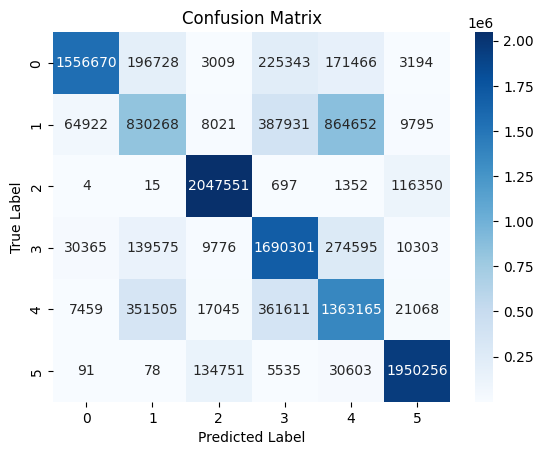

In [ ]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y1_test_classes_flat, y1_pred_classes_flat)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
classification = classification_report(y1_test_classes_flat, y1_pred_classes_flat)
print("Classification Report:\n")
print(classification)

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.72      0.82   2156410
           1       0.55      0.38      0.45   2165589
           2       0.92      0.95      0.93   2165969
           3       0.63      0.78      0.70   2154915
           4       0.50      0.64      0.56   2121853
           5       0.92      0.92      0.92   2121314

    accuracy                           0.73  12886050
   macro avg       0.74      0.73      0.73  12886050
weighted avg       0.74      0.73      0.73  12886050



In [14]:
from collections import Counter

def signal_detection_metrics(test_classes, pred_classes, signal_classes):
    """
    Calculate the following metrics for each specified class:
    1) Percentage of actual signal events detected w.r.t total signal events.
    2) Percentage of actual signal detected w.r.t. the predicted signal events.
    3) Breakdown of misclassified predictions for each class.
    4) Total number of events classified as the given class.

    Parameters:
    - test_classes: Array-like, ground truth labels
    - pred_classes: Array-like, predicted labels
    - signal_classes: int or list, class/classes for which the metrics should be computed

    Returns:
    - A dictionary containing results for each class.
    """
    
    # Ensure signal_classes is a list
    if isinstance(signal_classes, int):
        signal_classes = [signal_classes]
    
    # Convert to NumPy arrays for easier computation
    test_classes = np.array(test_classes)
    pred_classes = np.array(pred_classes)

    results = {}

    for cls in signal_classes:
        # True Positives (TP): cases where both test and pred match the class
        tp = np.sum((test_classes == cls) & (pred_classes == cls))
        
        # Total actual signal events for the class
        total_signal_events = np.sum(test_classes == cls)
        
        # Total predicted signal events for the class
        total_predicted_signal = np.sum(pred_classes == cls)

        # Compute percentages
        percentage_actual_signal_detected = (tp / total_signal_events * 100) if total_signal_events > 0 else 0
        percentage_detected_signal_accuracy = (tp / total_predicted_signal * 100) if total_predicted_signal > 0 else 0

        # Misclassification breakdown: Find what other classes were mistaken as this class
        misclassified_counts = Counter(test_classes[pred_classes == cls])
        if cls in misclassified_counts:
            del misclassified_counts[cls]  # Remove true positives from misclassification count

        # Convert misclassification counts to percentages
        misclassification_percentages = {other_cls: (count / total_predicted_signal * 100) 
                                         for other_cls, count in misclassified_counts.items()}

        # Store results
        results[cls] = {
            "Total events classified as this class": total_predicted_signal,
            "Percentage of actual signal events detected": percentage_actual_signal_detected,
            "Percentage of detected signal accuracy": percentage_detected_signal_accuracy,
            "Misclassification breakdown (%)": misclassification_percentages
        }

    # Print results
    for cls, metrics in results.items():
        print(f"\nResults for class {cls}:")
        print(f"  - Total events classified as this class: {metrics['Total events classified as this class']}")
        print(f"  - Percentage of actual signal events detected: {metrics['Percentage of actual signal events detected']:.2f}%")
        print(f"  - Percentage of detected signal accuracy: {metrics['Percentage of detected signal accuracy']:.2f}%")

        if metrics["Misclassification breakdown (%)"]:
            print(f"  - Misclassified as other classes:")
            for mis_cls, mis_perc in metrics["Misclassification breakdown (%)"].items():
                print(f"    - Class {mis_cls}: {mis_perc:.2f}%")

    return results

In [ ]:
result = signal_detection_metrics(y1_test_classes_flat, y1_pred_classes_flat, [1, 2])
print(result)


Results for class 1:
  - Total events classified as this class: 1518169
  - Percentage of actual signal events detected: 38.34%
  - Percentage of detected signal accuracy: 54.69%
  - Misclassified as other classes:
    - Class 4: 23.15%
    - Class 3: 9.19%
    - Class 0: 12.96%
    - Class 5: 0.01%
    - Class 2: 0.00%

Results for class 2:
  - Total events classified as this class: 2220153
  - Percentage of actual signal events detected: 94.53%
  - Percentage of detected signal accuracy: 92.23%
  - Misclassified as other classes:
    - Class 5: 6.07%
    - Class 3: 0.44%
    - Class 4: 0.77%
    - Class 0: 0.14%
    - Class 1: 0.36%

Results for class 4:
  - Total events classified as this class: 2705833
  - Percentage of actual signal events detected: 64.24%
  - Percentage of detected signal accuracy: 50.38%
  - Misclassified as other classes:
    - Class 3: 10.15%
    - Class 0: 6.34%
    - Class 1: 31.96%
    - Class 5: 1.13%
    - Class 2: 0.05%

Results for class 5:
  - Total e

In [ ]:
X1_test = rp.X1_seq_test

In [17]:
import joblib

# Load the saved scalers
min_max_scaler = joblib.load("../scalers/min_max_scaler.pkl")
robust_scaler = joblib.load("../scalers/robust_scaler.pkl")

In [20]:
energy_column_idx = 0
r_column_idx = 1     # r is the 2nd feature
z_column_idx = 2     # z is the 3rd feature
phi_column_idx = 3 

In [ ]:
# Flatten X_test to 2D (samples * timesteps, features)
X1_test_flat = X1_test.reshape(-1, X1_test.shape[-1])  # Shape: (samples * timesteps, features)

In [ ]:
# Apply inverse transformation
X1_test_flat[:, [energy_column_idx, r_column_idx]] = min_max_scaler.inverse_transform(
    X1_test_flat[:, [energy_column_idx, r_column_idx]]
)

X1_test_flat[:, z_column_idx] = robust_scaler.inverse_transform(
    X1_test_flat[:, z_column_idx].reshape(-1, 1)
).reshape(X1_test_flat[:, z_column_idx].shape)



# Recover phi from sin(phi)
X1_test_flat[:, phi_column_idx] = np.arcsin(X1_test_flat[:, phi_column_idx])



In [ ]:
def plot_histograms(X, predictions, model_name, feature_names, save_dir="../plots/LSTM(whole)"):
    """
    Plots and saves histograms for each feature and each predicted class separately.

    Parameters:
        X (numpy array or pandas DataFrame): Feature data.
        predictions (numpy array): Predicted class labels.
        model_name (str): Name of the model (for plot titles and filenames).
        feature_names (list of str): Names of the features.
        save_dir (str): Directory to save the plots (default: '../plots/LSTM(whole)').
    """
    # Mapping class labels to their corresponding names
    class_labels = {
        0: "Internal Background",
        1: "Bi214",
        2: "Po214",
        3: "External Background",
        4: "Bi212",
        5: "Po212"
    }

    # Define units for specific features
    feature_units = {
        "Energy": "MeV",
        "r": "mm",
        "z": "mm",
        "phi": "radian",
        "Time Difference": "seconds",
        "Distance": "mm"
    }

    # Ensure save directory exists
    os.makedirs(save_dir, exist_ok=True)

    # Ensure X is a NumPy array
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()

    for feature_idx, feature_name in enumerate(feature_names):
        for class_label in np.unique(predictions):
            plt.figure(figsize=(10, 6))
            
            # Filter the data for the current class
            class_data = X[predictions == class_label, feature_idx]
            
            # Get the class name
            class_name = class_labels.get(class_label, f"Class {class_label}")

            # Determine the x-axis label (add units if available)
            unit = feature_units.get(feature_name, "")
            x_label = f"{feature_name} ({unit})" if unit else feature_name

            # Plot histogram for the current feature and class
            plt.hist(class_data, bins=50, alpha=0.7, color='blue')
            plt.title(f'Histogram of {feature_name} ({class_name}) - {model_name}')
            plt.xlabel(x_label)
            plt.ylabel('Frequency')
            plt.grid(True)

            # Format filename and save
            filename = os.path.join(save_dir, f"{model_name}_{feature_name}_{class_name}.png".replace(" ", "_"))
            plt.savefig(filename, dpi=300)
            plt.close()  # Close the figure to free memory

            print(f"Saved: {filename}")


In [30]:
# Feature names
feature_names = ['energy', 'r', 'z', 'phi', 'time_diff', 'distance']

In [ ]:
# Plot for model_1_2
plot_histograms(X1_test_flat, y1_pred_classes_flat, "LSTM (Model 214)", feature_names)

Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_energy_Internal_Background.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_energy_Bi214.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_energy_Po214.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_energy_External_Background.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_energy_Bi212.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_energy_Po212.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_r_Internal_Background.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_r_Bi214.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_r_Po214.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_r_External_Background.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_r_Bi212.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_r_Po212.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_z_Internal_Background.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_z_Bi214.png
Saved: ../plots/LSTM(whole)/LSTM_(Whole_Chain)_z_Po214.png
Saved: ../plots

# Predictions of the Model 212 on just 212 events and background

In [ ]:
y2_pred = model2.predict(rp.X2_seq_test) 

In [ ]:
#convert predictions to class labels
y2_pred_classes = np.argmax(y2_pred, axis=2)

# Convert one-hot encoded true labels back to class labels
y2_test_classes = np.argmax(rp.y2_seq_test, axis=2)

In [ ]:
# Reshape or flatten the arrays
y2_test_classes_flat = y2_test_classes.reshape(-1)  # Flatten y_test_classes1
y2_pred_classes_flat = y2_pred_classes.reshape(-1)  # Flatten y_pred_classes1

In [ ]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y2_test_classes_flat, y2_pred_classes_flat)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
classification = classification_report(y2_test_classes_flat, y2_pred_classes_flat)
print("Classification Report:\n")
print(classification)

In [ ]:
result = signal_detection_metrics(y2_test_classes_flat, y2_pred_classes_flat, [1, 2])
print(result)

In [ ]:
X2_test = rp.X2_seq_test

In [ ]:
# Flatten X_test to 2D (samples * timesteps, features)
X2_test_flat = X2_test.reshape(-1, X2_test.shape[-1])  # Shape: (samples * timesteps, features)

In [ ]:
# Apply inverse transformation
X2_test_flat[:, [energy_column_idx, r_column_idx]] = min_max_scaler.inverse_transform(
    X2_test_flat[:, [energy_column_idx, r_column_idx]]
)

X2_test_flat[:, z_column_idx] = robust_scaler.inverse_transform(
    X2_test_flat[:, z_column_idx].reshape(-1, 1)
).reshape(X2_test_flat[:, z_column_idx].shape)



# Recover phi from sin(phi)
X2_test_flat[:, phi_column_idx] = np.arcsin(X2_test_flat[:, phi_column_idx])

In [ ]:
# Plot for model_1_2
plot_histograms(X2_test_flat, y2_pred_classes_flat, "LSTM (Model 212)", feature_names)

In [ ]:
# Clear memory associated with the module
import gc
del rp
if 'RNN_preprocessing_sep_chain' in sys.modules:
    del sys.modules['RNN_preprocessing_sep_chain']

# Clear memory from global variables if needed
gc.collect()

# Combined Prediction

In [ ]:
import RNN_preprocessing_whole as rp

In [ ]:
X_test = rp.X_seq_test
y_test = rp.y_seq_test

In [ ]:
del rp
if 'RNN_preprocessing_whole' in sys.modules:
    del sys.modules['RNN_preprocessing_whole']

# Clear memory from global variables if needed
gc.collect()

In [ ]:
y1_pred_comb = model1.predict(X_test) 

In [ ]:
y2_pred_comb = model2.predict(X2_test) 

In [ ]:
#convert predictions to class labels
y1_pred_classes_comb = np.argmax(y1_pred_comb, axis=2)

y2_pred_classes_comb = np.argmax(y2_pred_comb, axis=2)

# Convert one-hot encoded true labels back to class labels
y_test_classes = np.argmax(y_test, axis=2)

In [ ]:
# Reshape or flatten the arrays
y_test_classes_flat = y_test_classes.reshape(-1)  # Flatten y_test_classes1
y1_pred_classes_comb_flat = y1_pred_classes_comb.reshape(-1)
y2_pred_classes_comb_flat = y2_pred_classes_comb.reshape(-1)  # Flatten y_pred_classes1

In [ ]:
def comb_pred(model1_probs, model2_probs):
    """
    Resolves conflicts between two model predictions for sequence data.

    Parameters:
        model1_probs (numpy array): Probabilities from model 1, shape (num_sequences, seq_length, num_classes).
        model2_probs (numpy array): Probabilities from model 2, shape (num_sequences, seq_length, num_classes).

    Returns:
        numpy array: Final predicted labels, shape (num_sequences, seq_length).
    """
    # Get shape parameters
    num_sequences, seq_length, num_classes = model1_probs.shape
    
    # Initialize final predictions
    final_prediction = np.zeros((num_sequences, seq_length), dtype=int)

    # Iterate over sequences
    for seq in range(num_sequences):
        for t in range(seq_length):
            # Get predicted class and probability for both models at timestep t
            model1_pred = np.argmax(model1_probs[seq, t])  # Model 1's predicted class
            model1_prob = model1_probs[seq, t, model1_pred]  # Model 1's probability
            
            model2_pred = np.argmax(model2_probs[seq, t])  # Model 2's predicted class
            model2_prob = model2_probs[seq, t, model2_pred]  # Model 2's probability

            # If either model predicts class 0 or 3, use that class
            if model1_pred == 0 or model2_pred == 0:
                final_prediction[seq, t] = 0
            elif model1_pred == 3 or model2_pred == 3:
                final_prediction[seq, t] = 3
            else:
                # Resolve conflict when models predict different classes
                if model1_pred in [1, 2] and model2_pred in [4, 5]:
                    # Choose the model with the higher confidence
                    if model1_prob > model2_prob:
                        final_prediction[seq, t] = model1_pred
                    else:
                        final_prediction[seq, t] = model2_pred
                elif model1_pred in [1, 2]:
                    final_prediction[seq, t] = model1_pred
                elif model2_pred in [4, 5]:
                    final_prediction[seq, t] = model2_pred

    return final_prediction


In [ ]:
final_preds = comb_pred(y1_pred_comb, y2_pred_comb)  # Keep 3D structure!

In [ ]:
y_pred_comb = np.argmax(final_preds, axis=2)

In [ ]:
y_pred = y_pred_comb.reshape(-1) 

In [ ]:
# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_classes_flat, y_pred)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Step 8: Print the classification report (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test_classes_flat, y_pred))


In [ ]:
# Flatten X_test to 2D (samples * timesteps, features)
X_test_flat = X_test.reshape(-1, X_test.shape[-1])  # Shape: (samples * timesteps, features)

In [ ]:
# Apply inverse transformation
X_test_flat[:, [energy_column_idx, r_column_idx]] = min_max_scaler.inverse_transform(
    X_test_flat[:, [energy_column_idx, r_column_idx]]
)

X_test_flat[:, z_column_idx] = robust_scaler.inverse_transform(
    X_test_flat[:, z_column_idx].reshape(-1, 1)
).reshape(X_test_flat[:, z_column_idx].shape)



# Recover phi from sin(phi)
X_test_flat[:, phi_column_idx] = np.arcsin(X_test_flat[:, phi_column_idx])

In [ ]:
# Plot for model_1_2
plot_histograms(X_test_flat, y1_pred_classes_comb_flat, "LSTM (Model 214 for the dataset with both chains)", feature_names)

In [ ]:
plot_histograms(X_test_flat, y2_pred_classes_comb_flat, "LSTM (Model 212 for the dataset with both chains)", feature_names)

In [ ]:
plot_histograms(X_test_flat, y_pred, "LSTM (Both models combined)", feature_names)